In [13]:
# Statsmodels AIC and Feature Engineering Vignette Using Hitters

# The goal of this vignette is to teach you some of the basics of statsmodels and also
# show you how to construct meaningful features and to use AIC for model selection. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns
from ISLP import load_data


Hitters = load_data('Hitters').dropna(subset=['Salary'])
Hitters.shape

(263, 20)

In [45]:
# In lieu of making a lot of plots for an EDA, we will just look at correlations with the
# target and a correlation matrix. We see importance of career stats, and that some other stats
# are also important. Defensive stats seem irrelevant

Hitters.corr(numeric_only=True)['Salary'].drop('Salary').abs().sort_values(ascending=False)


log_salary       0.895437
resid            0.592540
CRBI_rate        0.580406
CRBI             0.566966
CRuns            0.562678
CHits_rate       0.558572
CHits            0.548910
CRuns_rate       0.547637
CAtBat           0.526135
CHmRun           0.524931
CAtBat_rate      0.504918
years_feature    0.494403
CWalks           0.489822
CWalks_rate      0.477095
resid2           0.454960
RBI              0.449457
Walks            0.443867
Hits             0.438675
Runs             0.419859
Years            0.400657
AtBat            0.394771
HmRun            0.343028
PutOuts          0.300480
Assists          0.025436
Errors           0.005401
Name: Salary, dtype: float64

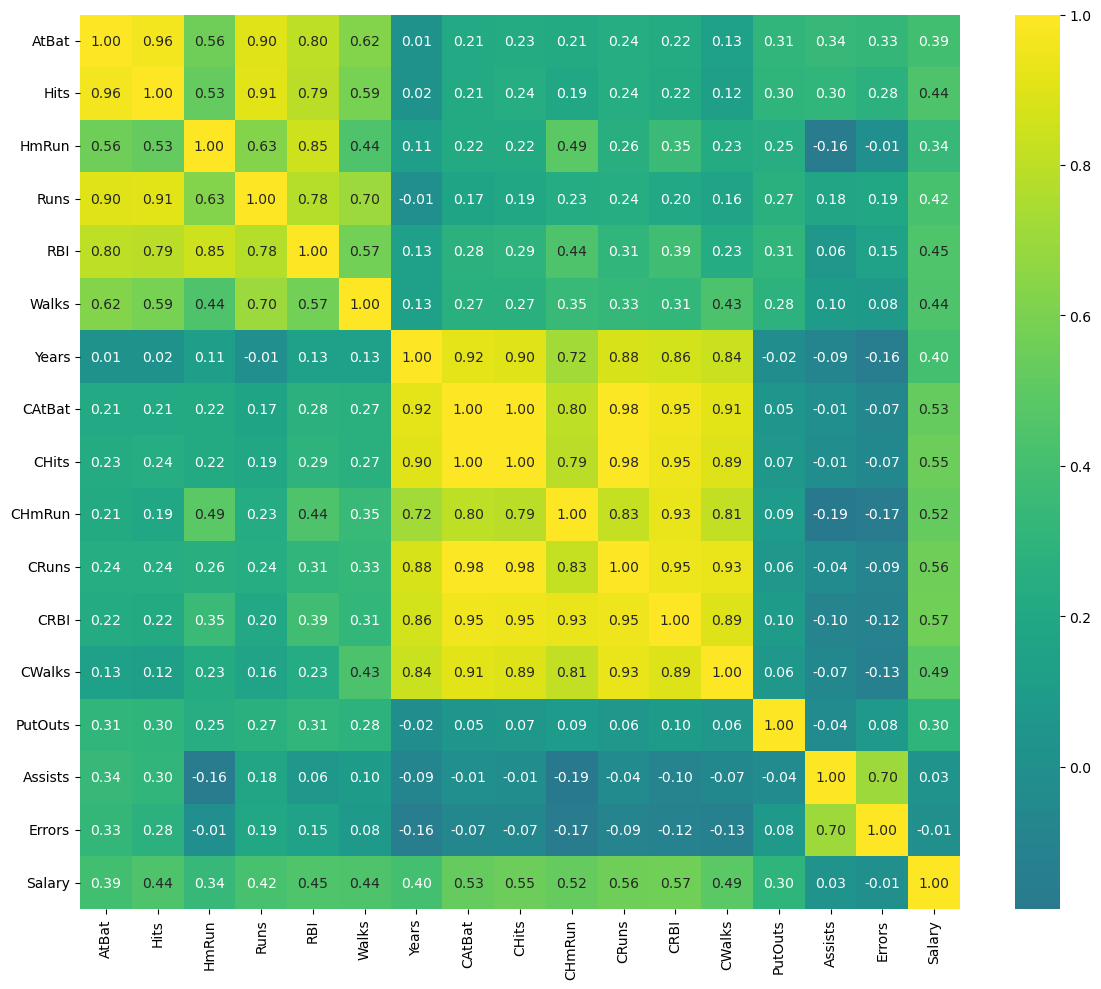

In [ ]:
# The correlation heatmap shows that most offensive statistics are correlated, either on the "year level" or
# on the career level

corr = Hitters.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis', center=0)
plt.tight_layout()
plt.show()



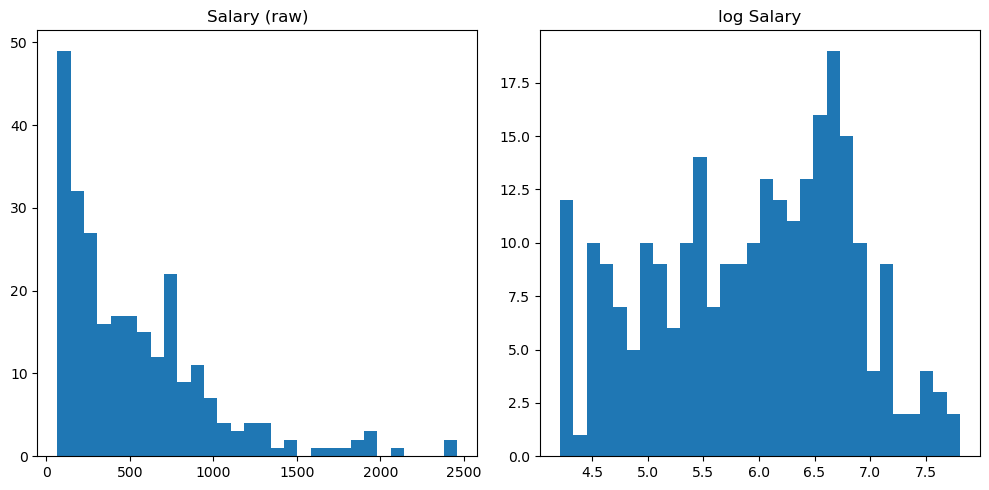

In [ ]:
# We are going to log transform salary, here you can see why, it has a heavily skewed, long tailed distribution


Hitters['log_salary'] = np.log(Hitters['Salary'])

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].hist(Hitters['Salary'], bins=30)
ax[0].set_title('Salary)')
ax[1].hist(Hitters['log_salary'], bins=30)
ax[1].set_title('log Salary')
plt.tight_layout()

In [ ]:
# We start by making a baseline model. We will just throw in a number of stats that are positive
# for a baseball player. 

baseline = smf.ols('log_salary ~ Hits + Walks + HmRun + PutOuts', data=Hitters).fit()
baseline.summary()

# The R^2 seems a bit small, clearly there is a great deal missing just from these simple statistics. This shows
# that prior year performance only plays minor role in next year salary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.244
Method:                 Least Squares   F-statistic:                     22.15
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           9.81e-16
Time:                        17:36:53   Log-Likelihood:                -302.97
No. Observations:                 263   AIC:                             615.9
Df Residuals:                     258   BIC:                             633.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8494      0.128     37.989      0.000       4.598       5.101
Hits           0.0049      0.001      3.430      0.001       0.002       0.008
Walks          0.0094      0.003      3.365      0.001       0.004       0.015
HmRun          0.0093      0.007      1.418      0.157      -0.004       0.022
PutOuts        0.0002      0.000      1.103      0.271      -0.000       0.001
==============================================================================
Omnibus:                        2.356   Durbin-Watson:                   1.922
Prob(Omnibus):                  0.308   Jarque-Bera (JB):                2.434
Skew:                          -0.216   Prob(JB):                        0.296
Kurtosis:                       2.810   Cond. No.                     1.11e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Now we make a suite of models, using the most important stats from our correlation
# calculation and increasing the complexity

model_basic = smf.ols('log_salary ~ CRBI + CWalks + CRuns',data=Hitters).fit()
model_intelligent = smf.ols('log_salary ~ CRBI + CWalks+ CRuns  + Walks  +  Division + AtBat +  CAtBat + PutOuts + Hits + CHits ',data=Hitters).fit()
model_the_works = smf.ols('log_salary ~ CRBI + CWalks + CRuns + RBI + Walks + Runs + CHmRun + Years + Errors + Assists + League + Division + AtBat + CAtBat + PutOuts + Hits + CHits + HmRun',data=Hitters).fit()

models = ["basic","intelligent","everything"]
aics = [model_basic.aic,model_intelligent.aic,model_the_works.aic]
aic_df = pd.DataFrame({'models':models,'aic':aics})

aic_df.sort_values('aic')

# The outcome is that a model that does not use every variable is superior based on AIC. It is likely that
# the mode that used every variable had a higher R^2, but the penalty for those extra coefficients overcame
# the training accuracy

,models,aic
1,intelligent,503.161313
2,everything,507.916203
0,basic,559.377771


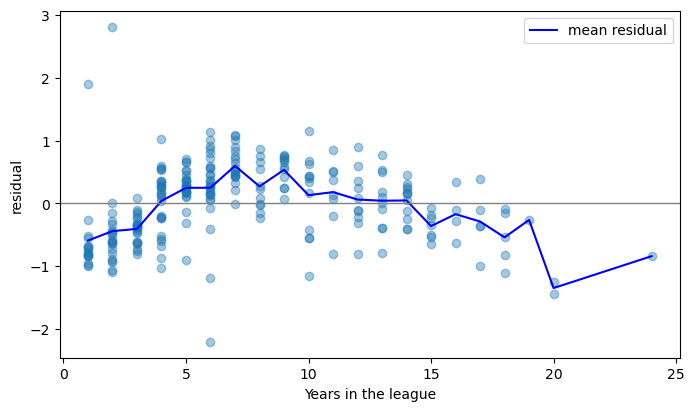

In [ ]:
# Let's take the intelligent model and see if we can understand its performance

Hitters['resid'] = model_intelligent.resid

fig, ax = plt.subplots(figsize=(8,4.5))
ax.scatter(Hitters['Years'], Hitters['resid'], alpha=0.4)
by_year = Hitters.groupby('Years')['resid'].mean()
ax.plot(by_year.index, by_year.values, '-', color='blue', label='mean residual')
ax.axhline(0, color='gray', lw=1)
ax.set_xlabel('Years in the league')
ax.set_ylabel('residual')
ax.legend()

# We can see that the residual exhibits a nonlinear pattern, a negative residual for young players, a positive residual for 
# players in the middle of their career, and a negative residual again for older players.
# This motivates performing feature engineering based on Years

In [ ]:
# Another motivation for applying feature engineering based on years is that the MLB had rules that governed player
# salaries. Player salaries were restricted in the first 6 years, and after year 6 players could sign in free 
# agency which was basically an open market

# We will create two features, both piecewise functions

Hitters['years_young'] = np.minimum(Hitters['Years'],6)
Hitters['years_old'] = np.maximum(Hitters['Years'],6)

# This is a helper string to make our model strings compact

base = ('log_salary ~ CRBI + CWalks + CRuns + Walks + Division'
        ' + AtBat + CAtBat + PutOuts + Hits + CHits +')

model_intelligent_years = smf.ols(base + 'Years',data=Hitters).fit()
model_intelligent_years_squared = smf.ols(base + 'Years + I(Years**2)',data=Hitters).fit()
model_intelligent_years_log = smf.ols(base + 'np.log(Years)',data=Hitters).fit()
model_intelligent_years_cap_young = smf.ols(base + 'years_young',data=Hitters).fit()
model_intelligent_years_cap_full = smf.ols(base + 'years_young +years_old',data=Hitters).fit()

models = ['intelligent','years','years quadratic','log','cap young','cap full']

aics = [model_intelligent.aic,
        model_intelligent_years.aic,
        model_intelligent_years_squared.aic,
        model_intelligent_years_log.aic,
        model_intelligent_years_cap_young.aic,
        model_intelligent_years_cap_full.aic]


aics_df = pd.DataFrame({'model':models,'aic':aics})

aics_df.sort_values('aic')


# We find that using both engineered features yields the best model, though the quadratic model is also close

,model,aic
5,cap full,385.297225
2,years quadratic,387.444691
4,cap young,404.617217
3,log,445.886333
1,years,500.026972
0,intelligent,503.161313


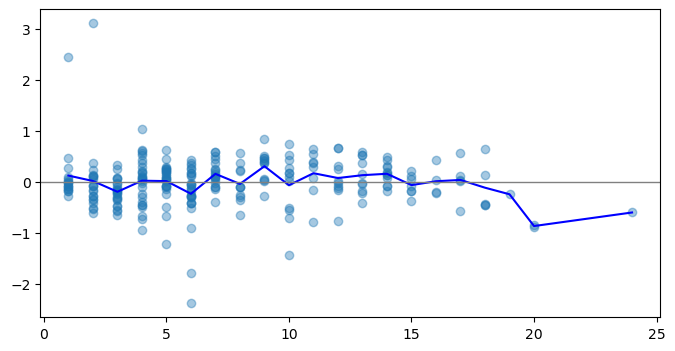

In [ ]:
# Now let us see the impact on the residuals

Hitters['resid'] = model_intelligent_years_cap_full.resid

fig, ax = plt.subplots(figsize=(8,4))
ax.scatter(Hitters['Years'], Hitters['resid'], alpha=0.4)
by_year = Hitters.groupby('Years')['resid'].mean()
ax.plot(by_year.index, by_year.values, '-', color='blue')
ax.axhline(0, color='gray', lw=1)

# Now the mean residual is very close to 0

In [53]:
# The next feature transformation we are going to apply is to convert "career" stats to averages per year,
# basically divide career rates by Years. This is an example of converting "extensive" variables into "intensive"
# variables. Extensive variables depend on the size of the system, intensive ones do not. You can see in the
# correlation heatmap that all of these career stats strongly correlate with year. So this takes out that correspondence

base_rate = 'log_salary ~ RBI_rate + Walks_rate + Runs_rate + Walks + Division + AtBat + AtBat_rate + PutOuts + Hits + Hits_rate +'

Hitters['RBI_rate'] = Hitters['RBI']/Hitters['Years']
Hitters['Walks_rate'] = Hitters['Walks']/Hitters['Years']
Hitters['Runs_rate'] = Hitters['CRuns']/Hitters['Years']
Hitters['AtBat_rate'] = Hitters['CAtBat']/Hitters['Years']
Hitters['Hits_rate'] = Hitters['CHits']/Hitters['Years']

model_intensive = smf.ols(base_rate + 'years_young +years_old',data=Hitters).fit()
model_intensive.summary()

# The final model has much improved performance both over the model with "extensive variables" and the original one


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_salary   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     56.05
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           7.82e-64
Time:                        23:38:37   Log-Likelihood:                -170.09
No. Observations:                 263   AIC:                             366.2
Df Residuals:                     250   BIC:                             412.6
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.1517      0.180     23.095      0.000       3.798       4.506
Division[T.W]    -0.0783      0.060     -1.303      0.194      -0.197       0.040
RBI_rate         -0.0015      0.005     -0.309      0.757      -0.011       0.008
Walks_rate       -0.0189      0.007     -2.701      0.007      -0.033      -0.005
Runs_rate         0.0073      0.005      1.427      0.155      -0.003       0.017
Walks             0.0089      0.002      3.675      0.000       0.004       0.014
AtBat            -0.0001      0.001     -0.127      0.899      -0.002       0.002
AtBat_rate       -0.0032      0.002     -1.910      0.057      -0.007       0.000
PutOuts           0.0003      0.000      2.676      0.008    8.05e-05       0.001
Hits             -0.0010      0.004     -0.273      0.785      -0.008       0.006
Hits_rate         0.0174      0.006      2.788      0.006       0.005       0.030
years_young       0.2320      0.033      6.974      0.000       0.167       0.298
years_old        -0.0239      0.011     -2.234      0.026      -0.045      -0.003
==============================================================================
Omnibus:                       97.560   Durbin-Watson:                   1.899
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1719.230
Skew:                           0.971   Prob(JB):                         0.00
Kurtosis:                      15.374   Cond. No.                     4.13e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.13e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""